In [1]:
#importing libraries
try:
    import pandas
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from PIL import Image
except Exception as e:
    print("Error: ",e)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cat.jpg to cat.jpg


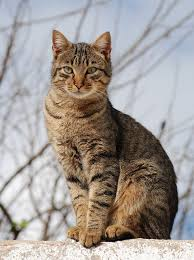

In [4]:
# importing and opening the image using pillow library
img_colored = Image.open("cat.jpg")
# print(img_colored)
# img_colored.show() opens in photos app
display(img_colored)

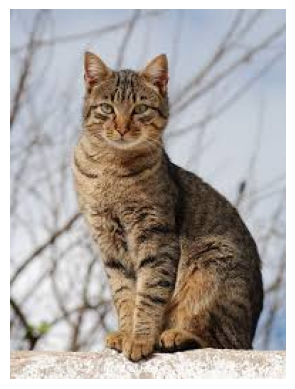

In [5]:
#displaying image using matplotlib
img = plt.imread("cat.jpg") #reading the image
plt.imshow(img) #displaying the image in a plot.
plt.axis("off") #removes the axis (x and y and their numbers) from the image
plt.show() #displays the plot window on the screen. this takes the image from the plot and displays it to us

# this might work without .show() as this is a jupyter notebook file .ipynb file so it auto calls .show() even if i dont write it but its good practive to write it though

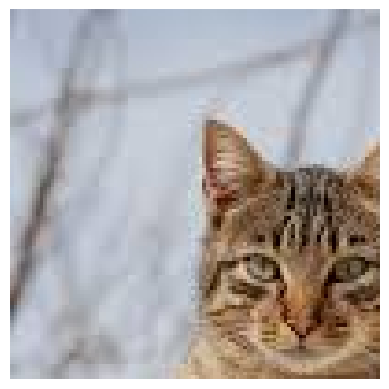

In [6]:
# displaying the top left corner 100 x 100 pixels and displaying using numpy and array indexing

img_array = np.array(img) #now this array has height, width and channels
top_left_img = img_array[:100,:100] #this is 100 x 100 even though 100 is exclusive cuz it goes from 0-99 which is 100 pixels
plt.imshow(top_left_img)
plt.axis("off")
plt.show()



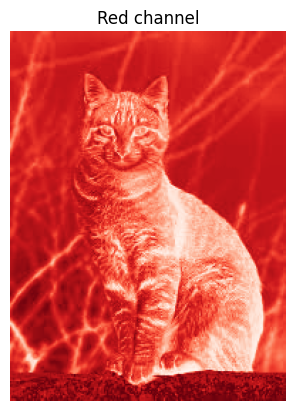

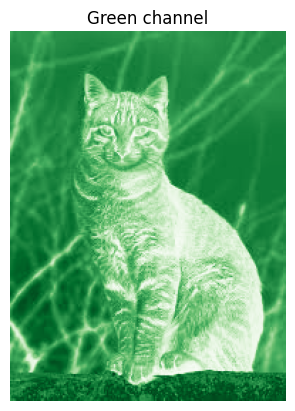

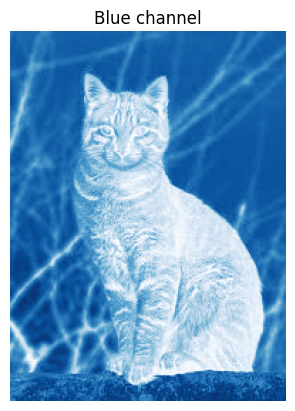

In [7]:
# displaying the three color channels

r=img_array[:,:,0] #taking all of row, all of column and 0 color channel which is R
g=img_array[:,:,1] #1 is for G
b=img_array[:,:,2] #2 is for B

plt.imshow(r,cmap="Reds")
plt.title("Red channel")
plt.axis("off")
plt.show()

plt.imshow(g,cmap="Greens")
plt.title("Green channel")
plt.axis("off")
plt.show()

plt.imshow(b,cmap="Blues")
plt.title("Blue channel")
plt.axis("off")
plt.show()

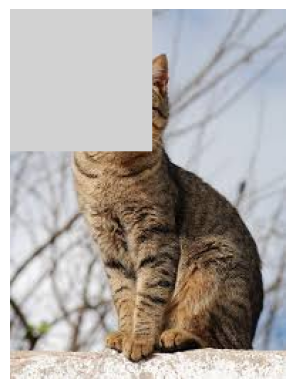

In [8]:
img_array[:100,:100,:] = 210
# plt.imshow(top_left_img)
mod_img = Image.fromarray(img_array)
plt.imshow(mod_img)
plt.axis("off")
plt.show()

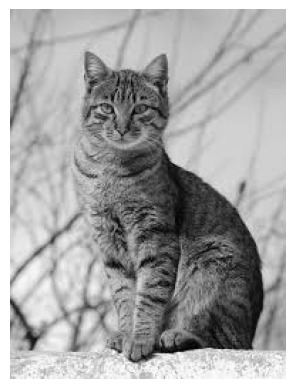

In [11]:
gray_img = Image.open("cat.jpg").convert("L")
# display(gray_img)
gray_arr = np.array(gray_img)
plt.imshow(gray_img, cmap="gray")
plt.axis("off")
plt.show()

(260, 194)
260 194


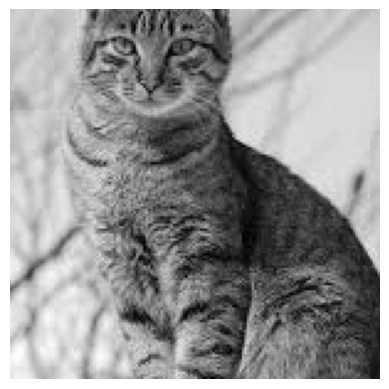

In [12]:
info = gray_arr.shape
print(info)
height=gray_arr.shape[0]
width=gray_arr.shape[1]
print(height,width)
center_row=height//2 #this will divide and round down to the closest whole number
center_col=width//2
half_size=150//2
row_start=center_row-half_size
row_end=center_row+half_size
col_start=center_col-half_size
col_end=center_col+half_size
center_img=gray_arr[row_start:row_end,col_start:col_end]
plt.imshow(center_img,cmap="gray")
plt.axis("off")
plt.show()

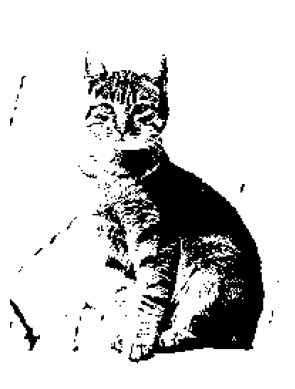

In [13]:
binary_img = np.zeros_like(gray_arr) #this makes an array of zeros of gray_arr size
binary_img[gray_arr>=100] =255 #here we are setting all pixel whose value is higher than 100 in gray_arr to 255 in binary_img
plt.imshow(binary_img, cmap="gray")
plt.axis("off")
plt.show()

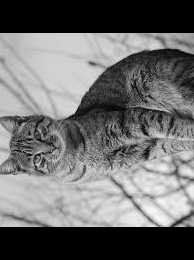

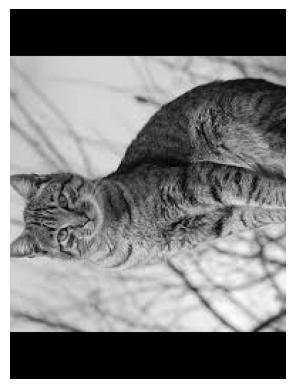

In [14]:
rotated_img = gray_img.rotate(90)
display(rotated_img)
#using matplotlib
plt.imshow(rotated_img,cmap="gray")
plt.axis("off")
plt.show()

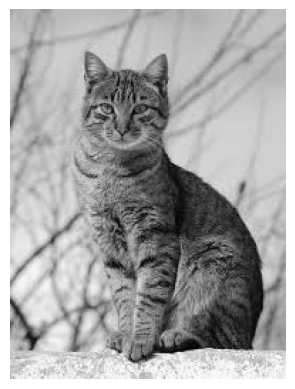

In [15]:
rgb_arr = np.stack((gray_arr,)*3,axis=-1)
rgb_img = Image.fromarray(rgb_arr)
plt.imshow(rgb_img)
plt.axis("off")
plt.show()

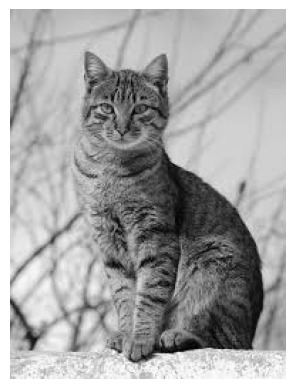

[[1101.70256905  943.78418473  711.00792991 ...   56.73047223
    42.33354618   61.75937036]
 [ 943.78418473  977.77871993  901.52833383 ...   76.05954856
    45.74067419   59.19293139]
 [ 711.00792991  901.52833383 1048.19358479 ...   90.96495396
    48.28681319   61.98907039]
 ...
 [  56.73047223   76.05954856   90.96495396 ...  476.5990496
   419.01054351  408.53460053]
 [  42.33354618   45.74067419   48.28681319 ...  419.01054351
   431.11272646  424.27912088]
 [  61.75937036   59.19293139   61.98907039 ...  408.53460053
   424.27912088  429.62542323]]


In [16]:
new_img = Image.open("cat.jpg").convert("L")
img_arr = np.array(new_img)
plt.imshow(new_img,cmap="gray")
plt.axis("off")
plt.show()

# getting the images dimensions
height, width = img_arr.shape
data = img_arr.reshape(height,width) #reshaping the image into a 2d array where each row represents a row of pixels
#this letes the PCA to process each row as on observation and find patters across pixels intensityies

# claculating the mean and standard deviation of each column/feature
mean = np.mean(data,axis=0)
std = np.std(data,axis=0)
# subtracting the mean to center the data
center_data = data-mean

# calculating the covariance matrix
cov_matrix = np.cov(center_data,rowvar=False)
print(cov_matrix)


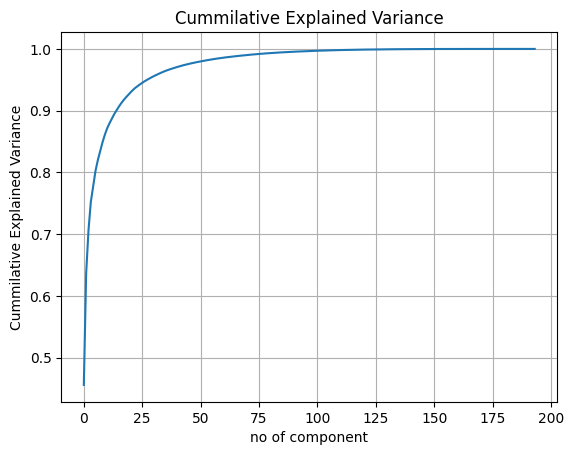

In [17]:
# calculating the eigen value and eigen vector of the covariance matrix
eigen_value, eigen_vector = np.linalg.eigh(cov_matrix)

# sorting the eigenvalues and corresponding eigenvectors in descending order
sorted_index = np.argsort(eigen_value)[::-1]
eigen_value = eigen_value[sorted_index]
eigen_vector = eigen_vector[:,sorted_index]

explained_variance_ratio = eigen_value/np.sum(eigen_value)
plt.plot(np.cumsum(explained_variance_ratio))
plt.title("Cummilative Explained Variance")
plt.xlabel("no of component")
plt.ylabel("Cummilative Explained Variance")
plt.grid()
plt.show()

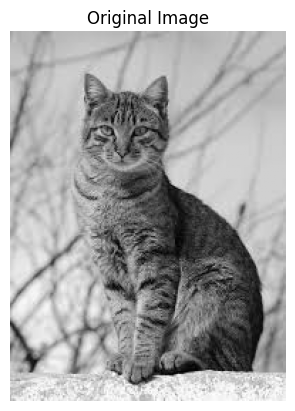

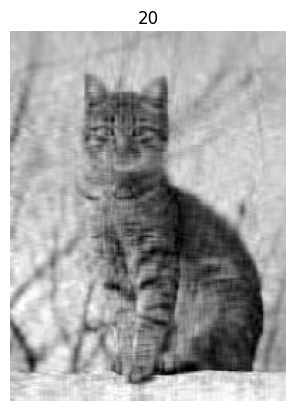

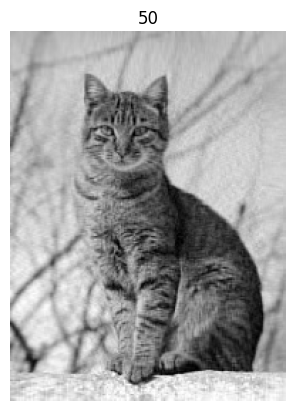

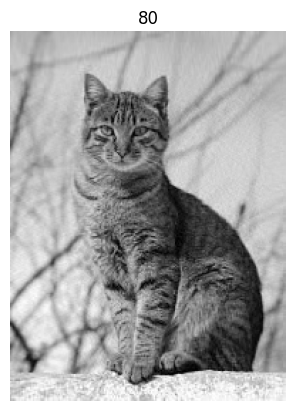

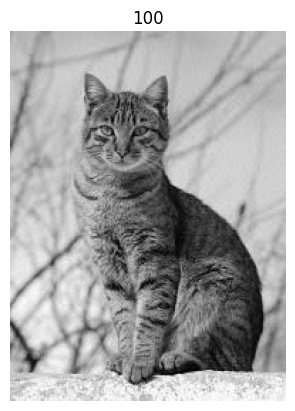

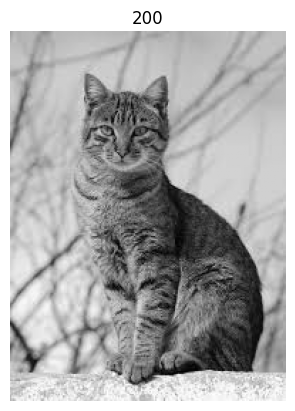

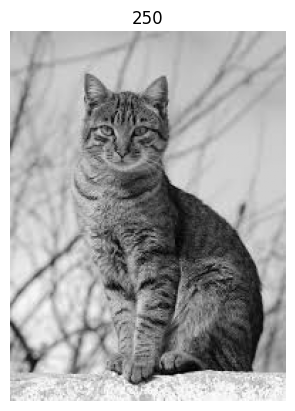

In [18]:
num_component_list = [20,50,80,100,200,250]
plt.imshow(new_img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

for i,num_componenet in enumerate(num_component_list):
    # selecting the top principle componenet
    top_eigenvector = eigen_vector[:,:num_componenet] #2d so row,column
    # project data onto these components
    reduced_data = np.dot(center_data,top_eigenvector)
    # reconstructing the image
    reconstruct_data = np.dot(reduced_data,top_eigenvector.T)+mean
    reconstruct_image = np.clip(reconstruct_data,0,255)

    plt.imshow(reconstruct_image,cmap="gray")
    plt.title(f"{num_componenet}")
    plt.axis("off")
    plt.show()
